# Assignment 1 — VT Alarm False Alarm classifacation 


Author: Mansour Arefi  
**Goal:** Predict whether a VT alarm event is **True** or **False** using the VTaC dataset.

Containing:
- Read labels + split CSVs and merge
- Explore available signals per event (WFDB headers)
- Clean/remove unreadable events
- Define two feature-set cases (Case 1 core, Case 2 extended)
- Extract simple time-window features around alarm onset
- Train and evaluate two baseline models (LogReg, RandomForest)
- Compare **drop vs impute** for missing waveforms (Case 2)
- Use feature importance + recursive selection to interpret the best model

**Project structure:**
- `raw_data/` is read-only input
- `processed_data/` contains small saved intermediate tables 
- `outputs/` contains plots and result tables
- `models/` contains saved fitted models


## 1. Imports, reproducibility, and paths


In [1]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb  

# Reproducibility
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

# Paths (relative paths -> reproducible)
DATA_DIR = Path("raw_data") / "vtac" / "1.0"
WAVEFORMS_DIR = DATA_DIR / "waveforms"
LABELS_CSV = DATA_DIR / "event_labels.csv"
SPLIT_CSV  = DATA_DIR / "benchmark_data_split.csv"

# Output folders
PROCESSED_DIR = Path("processed_data")
OUT_DIR = Path("outputs")
MODELS_DIR = Path("models")
PROCESSED_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


## 2. Load CSV files and merge labels with benchmark split


In [2]:
#Loads files

labels_df = pd.read_csv(LABELS_CSV)   # record, event, decision
split_df  = pd.read_csv(SPLIT_CSV)    # split, record, event

print("labels_df shape:", labels_df.shape)
print("split_df shape :", split_df.shape)

display(labels_df.head())
display(split_df.head())

#Merge on [record and event]
df = labels_df.merge(split_df, on=["record", "event"], how="inner")
print("Merged df shape:", df.shape)

# Check if something was lost in the merge
lost_labels = len(labels_df) - len(df)
lost_split  = len(split_df) - len(df)
print("Rows lost from labels after merge:", lost_labels)
print("Rows lost from split after merge :", lost_split)

#create a targetvariable [1 = true, 0 = false]
df["decision_clean"] = df["decision"].astype(str).str.strip().str.upper()
df["y"] = df["decision_clean"].map({"FALSE": 0, "TRUE": 1})

missing_y = int(df["y"].isna().sum())
print("Missing y after mapping:", missing_y)

if missing_y > 0:
    print("Unexpected decision values (examples):")
    display(df.loc[df["y"].isna(), "decision"].value_counts().head(10))

#Some important counts
print("\nDecision counts (whole dataset):")
display(df["decision_clean"].value_counts())

print("\nSplit counts:")
display(df["split"].value_counts())

# True/False counts per split
counts_per_split = pd.crosstab(df["split"], df["decision_clean"])
counts_per_split["TOTAL"] = counts_per_split.sum(axis=1)

# Percent per split
pct_per_split = counts_per_split.div(counts_per_split["TOTAL"], axis=0) * 100

print("\nCounts per split (True/False):")
display(counts_per_split)

print("\nPercent per split (True/False):")
display(pct_per_split.round(2))

#Save this merged files
PROCESSED_DIR = Path("processed_data")
PROCESSED_DIR.mkdir(exist_ok=True)

merged_path = PROCESSED_DIR / "events_merged.csv"
df.to_csv(merged_path, index=False)

print("\nSaved merged file to:", merged_path)


labels_df shape: (5037, 3)
split_df shape : (5037, 3)


,record,event,decision
0,003c13,003c13_0115,False
1,003c13,003c13_0126,False
2,004bad,004bad_0015,False
3,004bad,004bad_1115,False
4,004bad,004bad_1426,False


,split,record,event
0,train,003c13,003c13_0115
1,train,003c13,003c13_0126
2,train,004bad,004bad_0015
3,train,004bad,004bad_1115
4,train,004bad,004bad_1426


Merged df shape: (5037, 4)
Rows lost from labels after merge: 0
Rows lost from split after merge : 0
Missing y after mapping: 0

Decision counts (whole dataset):


decision_clean
FALSE    3596
TRUE     1441
Name: count, dtype: int64

...


Counts per split (True/False):


decision_clean,FALSE,TRUE,TOTAL
split,,,
test,345,137,482
train,2897,1163,4060
val,354,141,495



Percent per split (True/False):


decision_clean,FALSE,TRUE,TOTAL
split,,,
test,71.58,28.42,100.0
train,71.35,28.65,100.0
val,71.52,28.48,100.0



Saved merged file to: processed_data\events_merged.csv


## 3. Explore events: available signals per event (WFDB headers only)
Which signals appears on every events


In [3]:
# 3) Explore events (WFDB headers only)
import utility_functions


# Scan headers for all events 
df = utility_functions.scan_wfdb_headers(df, WAVEFORMS_DIR)

print("Header success rate:", df["header_ok"].mean())
print("Failed header reads:", (~df["header_ok"]).sum())

# Show some failed examples 
failed_examples = df.loc[df["header_ok"] == False, ["record", "event", "split", "decision", "header_error"]].head(10)
display(failed_examples)

# Sampling rate check (fs)
fs_counts, fs_mismatch = utility_functions.summarize_sampling_rate(df, expected_fs=250.0)

print("\nSampling rate (fs) counts among readable events:")
display(fs_counts)

print("\nEvents with fs != 250 (if any):")
display(fs_mismatch.head(10))
print("Number of fs mismatches:", len(fs_mismatch))

# Signal availability statistics
sig_counts = utility_functions.compute_sig_name_counts(df)

print("\nTop 20 signal names:")
display(sig_counts.head(20))

# Save important processed files
PROCESSED_DIR = Path("processed_data")
PROCESSED_DIR.mkdir(exist_ok=True)

events_with_headers_path = PROCESSED_DIR / "events_with_headers.csv"
sig_counts_path = PROCESSED_DIR / "sig_name_counts.csv"

df.to_csv(events_with_headers_path, index=False)
sig_counts.to_csv(sig_counts_path)

print("\nSaved:", events_with_headers_path)
print("Saved:", sig_counts_path)


Header success rate: 0.9986102838991463
Failed header reads: 7


,record,event,split,decision,header_error
1322,45ae29,45ae29_0111,val,True,[Errno 2] No such file or directory: 'c:/Users...
2193,712013,712013_0407,train,True,[Errno 2] No such file or directory: 'c:/Users...
2194,712013,712013_0480,train,True,[Errno 2] No such file or directory: 'c:/Users...
2325,772573,772573_0857,val,True,[Errno 2] No such file or directory: 'c:/Users...
4455,e15b6a,e15b6a_0298,train,True,[Errno 2] No such file or directory: 'c:/Users...
4456,e15b6a,e15b6a_5705,train,False,[Errno 2] No such file or directory: 'c:/Users...
4696,edb57f,edb57f_0219,val,True,[Errno 2] No such file or directory: 'c:/Users...



Sampling rate (fs) counts among readable events:


fs
250.0    5030
Name: count, dtype: int64


Events with fs != 250 (if any):


,record,event,split,decision,fs


Number of fs mismatches: 0

Top 20 signal names:


,count,pct_events
sig_names,,
II,4989,99.184891
V,4768,94.791252
PLETH,4675,92.942346
AVR,3145,62.524851
I,1855,36.878728
III,1835,36.481113
ABP,1834,36.461233
AVL,169,3.359841
AVF,163,3.240557



Saved: processed_data\events_with_headers.csv
Saved: processed_data\sig_name_counts.csv


## 4. Clean events: remove unreadable events (missing WFDB headers)
Removed the 7 events that missing signals

In [4]:
# df currently contains header_ok, fs, sig_names, etc.
# Keep only readable events
df_clean = df[df["header_ok"] == True].copy()

n_before = len(df)
n_after = len(df_clean)
n_removed = n_before - n_after

print("Events before cleaning:", n_before)
print("Events after cleaning :", n_after)
print("Removed events        :", n_removed)

# save the removed events list for documentation
removed_df = df[df["header_ok"] == False][["record", "event", "split", "decision", "header_error"]].copy()
display(removed_df)

PROCESSED_DIR = Path("processed_data")
events_path = PROCESSED_DIR / "events_with_headers.csv"

# Overwrite the same file
df_clean.to_csv(events_path, index=False)
print("\nUpdated file saved to:", events_path)

# Also keep df_clean as the main dataframe from now on
df = df_clean

# Save removed list to outputs (documentation)
removed_out = OUT_DIR / "removed_events_missing_headers.csv"
removed_df.to_csv(removed_out, index=False)
print("Saved:", removed_out)


Events before cleaning: 5037
Events after cleaning : 5030
Removed events        : 7


,record,event,split,decision,header_error
1322,45ae29,45ae29_0111,val,True,[Errno 2] No such file or directory: 'c:/Users...
2193,712013,712013_0407,train,True,[Errno 2] No such file or directory: 'c:/Users...
2194,712013,712013_0480,train,True,[Errno 2] No such file or directory: 'c:/Users...
2325,772573,772573_0857,val,True,[Errno 2] No such file or directory: 'c:/Users...
4455,e15b6a,e15b6a_0298,train,True,[Errno 2] No such file or directory: 'c:/Users...
4456,e15b6a,e15b6a_5705,train,False,[Errno 2] No such file or directory: 'c:/Users...
4696,edb57f,edb57f_0219,val,True,[Errno 2] No such file or directory: 'c:/Users...



Updated file saved to: processed_data\events_with_headers.csv
Saved: outputs\removed_events_missing_headers.csv


## 5. Signal availability: how common are II, V, and PLETH?
Looking for the amount of events that containing all three II + V + PLETH at the same time


In [5]:

# Make a set of signal names for each event
df["sig_set"] = df["sig_names"].apply(lambda lst: {str(s).strip().upper() for s in lst})

# Check presence
df["has_II"] = df["sig_set"].apply(lambda s: "II" in s)
df["has_V"] = df["sig_set"].apply(lambda s: "V" in s)
df["has_PLETH"] = df["sig_set"].apply(lambda s: "PLETH" in s)

# All three together
df["has_II_V_PLETH"] = df["has_II"] & df["has_V"] & df["has_PLETH"]

# Total 
n_total = len(df)
n_all3 = int(df["has_II_V_PLETH"].sum())
pct_all3 = 100 * n_all3 / n_total

print(f"Total events: {n_total}")
print(f"Events with II+V+PLETH: {n_all3} ({pct_all3:.2f}%)")

# Per split 
by_split = df.groupby("split")["has_II_V_PLETH"].agg(["sum", "count"])
by_split["pct"] = 100 * by_split["sum"] / by_split["count"]

print("\nPer split (II+V+PLETH availability):")
display(by_split)


Total events: 5030
Events with II+V+PLETH: 4394 (87.36%)

Per split (II+V+PLETH availability):


,sum,count,pct
split,,,
test,421,482,87.344398
train,3548,4056,87.475345
val,425,492,86.382114


## 6. Feature sets (two cases)

From the signal availability analysis, **II, V, PLETH** appear together in most events.
To keep the assignment simple but still compare strategies, we define two cases:

### Case 1 (core / baseline)
We use only the most common signals:
- **II, V, PLETH**
We drop events that do not contain all three signals.

### Case 2 (extended)
We extend the feature set by also using:
- **AVR, ABP**  
Some events do not have AVR/ABP, so we will compare:
- **DROP** rows with missing values
- **IMPUTE** missing values (median)


In [6]:
# Case 1: signals
CASE_1_SIGNALS = ["II", "V", "PLETH"]

# Make sure sig_set exists
if "sig_set" not in df.columns:
    df["sig_set"] = df["sig_names"].apply(lambda lst: {str(s).strip().upper() for s in lst})

# Check if all required signals exist
df["case1_all_present"] = df["sig_set"].apply(lambda s: all(sig in s for sig in CASE_1_SIGNALS))

# Create Case 1 dataframe (drop missing)
df_case1 = df[df["case1_all_present"] == True].copy()

# Report counts
n_total = len(df)
n_case1 = len(df_case1)

print(f"Total events: {n_total}")
print(f"Case 1 events (II+V+PLETH): {n_case1} ({100*n_case1/n_total:.2f}%)")

# Per split availability
case1_by_split = df.groupby("split")["case1_all_present"].agg(["sum", "count"])
case1_by_split["pct"] = 100 * case1_by_split["sum"] / case1_by_split["count"]

print("\nCase 1 availability per split:")
display(case1_by_split)


#True/False counts within Case 1 per split

# Ensure decision_clean exists (TRUE/FALSE)
if "decision_clean" not in df_case1.columns:
    df_case1["decision_clean"] = df_case1["decision"].astype(str).str.strip().str.upper()

case1_counts = pd.crosstab(df_case1["split"], df_case1["decision_clean"])
case1_counts["TOTAL"] = case1_counts.sum(axis=1)

case1_pct = case1_counts.div(case1_counts["TOTAL"], axis=0) * 100

print("\nWithin Case 1 events (II+V+PLETH):")
print("Counts per split (TRUE/FALSE):")
display(case1_counts)

print("\nWithin Case 1 events (II+V+PLETH):")
print("Percent per split (TRUE/FALSE):")
display(case1_pct.round(2))

# Save Case 1 event list
case1_path = PROCESSED_DIR / "events_case1_core.csv"
df_case1[["record", "event", "split", "decision", "y"]].to_csv(case1_path, index=False)
print("\nSaved:", case1_path)


Total events: 5030
Case 1 events (II+V+PLETH): 4394 (87.36%)

Case 1 availability per split:


,sum,count,pct
split,,,
test,421,482,87.344398
train,3548,4056,87.475345
val,425,492,86.382114



Within Case 1 events (II+V+PLETH):
Counts per split (TRUE/FALSE):


decision_clean,FALSE,TRUE,TOTAL
split,,,
test,303,118,421
train,2558,990,3548
val,309,116,425



Within Case 1 events (II+V+PLETH):
Percent per split (TRUE/FALSE):


decision_clean,FALSE,TRUE,TOTAL
split,,,
test,71.97,28.03,100.0
train,72.10,27.90,100.0
val,72.71,27.29,100.0



Saved: processed_data\events_case1_core.csv


## 7. Window around alarm onset

Each event is a 6-minute segment:
- 5 minutes before the alarm onset
- 1 minute after
So the alarm onset is at **300 seconds**.

**We use the same window for Case 1 and Case 2** to make comparisons fair:
- `PRE_SEC = 10` seconds before onset
- `POST_SEC = 5` seconds after onset

Motivation (simple):
- We want to capture the signal behavior *right around* the alarm trigger.
- A shorter window reduces noise from unrelated parts of the 6-minute record.


In [7]:
# Window settings (shared across Case 1 and Case 2)
PRE_SEC = 10
POST_SEC = 5
ONSET_SEC = 300
FS_EXPECTED = 250

print("Window:", PRE_SEC, "sec before onset and", POST_SEC, "sec after onset")


Window: 10 sec before onset and 5 sec after onset


## 8. Feature extraction (Case 1: II, V, PLETH)


In [8]:
import importlib
import utility_functions as uf
importlib.reload(uf)

# Settings for the window
PRE_SEC = 10
POST_SEC = 5
ONSET_SEC = 300  # 5 minutes
FS_EXPECTED = 250

# Extract features for each event in Case 1
feature_rows = []
fail_rows = []

for r, e in zip(df_case1["record"], df_case1["event"]):
    try:
        row = uf.extract_case1_features_for_event(
            record_id=r,
            event_id=e,
            waveforms_dir=WAVEFORMS_DIR,
            pre_sec=PRE_SEC,
            post_sec=POST_SEC,
            onset_sec=ONSET_SEC,
            fs_expected=FS_EXPECTED,
            signals=("II", "V", "PLETH")
        )
        feature_rows.append(row)
    except Exception as ex:
        fail_rows.append({"record": r, "event": e, "error": str(ex)})

features_case1 = pd.DataFrame(feature_rows)

print("Case 1 events:", len(df_case1))
print("Feature rows extracted:", len(features_case1))
print("Failed extractions:", len(fail_rows))

# Merge with labels + split
features_case1 = features_case1.merge(
    df_case1[["record", "event", "split", "decision", "y"]],
    on=["record", "event"],
    how="left"
)

display(features_case1.head())

# Missingness of features
# Only look at the feature columns (II_, V_, PLETH_)
feature_cols = [c for c in features_case1.columns 
                if c.startswith("II_") or c.startswith("V_") or c.startswith("PLETH_")]

missing_counts = features_case1[feature_cols].isna().sum()
missing_pct = (missing_counts / len(features_case1)) * 100

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

print("\nMissing values per feature (sorted):")
display(missing_table)

print("\nTop 10 features with highest missing %:")
display(missing_table.head(10))

# Also: how many rows have at least 1 missing feature
rows_with_missing = features_case1[feature_cols].isna().any(axis=1).sum()
print(f"\nRows with at least one missing feature: {rows_with_missing} / {len(features_case1)} "
      f"({100*rows_with_missing/len(features_case1):.2f}%)")

# Save 
features_path = PROCESSED_DIR / "features_case1.csv"
features_case1.to_csv(features_path, index=False)
print("Saved:", features_path)

# Only save failures if there are any 
if len(fail_rows) > 0:
    fail_df = pd.DataFrame(fail_rows)
    fail_path = PROCESSED_DIR / "features_case1_failed.csv"
    fail_df.to_csv(fail_path, index=False)
    print("Saved:", fail_path)


Case 1 events: 4394
Feature rows extracted: 4391
Failed extractions: 3


,record,event,fs,II_mean,II_std,II_min,II_max,II_ptp,II_rms,II_linelen,...,PLETH_mean,PLETH_std,PLETH_min,PLETH_max,PLETH_ptp,PLETH_rms,PLETH_linelen,split,decision,y
0,003c13,003c13_0115,250,-0.008637,0.177324,-0.440003,0.935029,1.375032,0.177535,127.684922,...,0.503368,0.139711,0.017585,0.846185,0.828600,0.522397,10.863723,train,False,0
1,003c13,003c13_0126,250,-0.001039,0.177053,-0.360011,0.924996,1.285008,0.177056,125.694006,...,0.477271,0.129744,0.000000,0.815911,0.815911,0.494592,14.331434,train,False,0
2,004bad,004bad_0015,250,0.117391,0.960125,-10.180360,1.889461,12.069820,0.967275,154.681022,...,0.500000,0.000000,0.500000,0.500000,0.000000,0.500000,0.000000,train,False,0
3,004bad,004bad_1115,250,0.069043,0.659609,-3.255062,7.150031,10.405093,0.663213,100.608654,...,0.448754,0.163268,0.059818,0.890629,0.830812,0.477532,16.822740,train,False,0
4,004bad,004bad_1426,250,0.108270,0.197246,-0.265001,1.074992,1.339993,0.225007,89.601199,...,0.413411,0.123236,0.182122,0.867675,0.685553,0.431388,16.617816,train,False,0



Missing values per feature (sorted):


,missing_count,missing_pct
PLETH_std,49,1.115919
PLETH_rms,49,1.115919
PLETH_ptp,49,1.115919
PLETH_linelen,49,1.115919
PLETH_max,49,1.115919
PLETH_mean,49,1.115919
PLETH_min,49,1.115919
V_min,27,0.614894
V_ptp,27,0.614894
V_mean,27,0.614894



Top 10 features with highest missing %:


,missing_count,missing_pct
PLETH_std,49,1.115919
PLETH_rms,49,1.115919
PLETH_ptp,49,1.115919
PLETH_linelen,49,1.115919
PLETH_max,49,1.115919
PLETH_mean,49,1.115919
PLETH_min,49,1.115919
V_min,27,0.614894
V_ptp,27,0.614894
V_mean,27,0.614894



Rows with at least one missing feature: 70 / 4391 (1.59%)
Saved: processed_data\features_case1.csv
Saved: processed_data\features_case1_failed.csv


## 9. Train baseline models (Case 1) and save fitted models
We drop any row that missing any feature before we train the models

In [9]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, balanced_accuracy_score, confusion_matrix
import joblib

# Load features (Case 1)

features_path = PROCESSED_DIR / "features_case1.csv"
features_case1 = pd.read_csv(features_path)

print("Loaded:", features_path)
print("Shape:", features_case1.shape)
display(features_case1.head())


# Select feature columns (only II/V/PLETH features)
feature_cols = [c for c in features_case1.columns if c.startswith("II_") or c.startswith("V_") or c.startswith("PLETH_")]
print("Number of feature columns:", len(feature_cols))
print("Example feature columns:", feature_cols[:10])


# Handle missing values (Case 1 baseline)
before = len(features_case1)
features_case1 = features_case1.dropna(subset=feature_cols).copy()
after = len(features_case1)

print("Dropped rows with NaN in features:", before - after)
print("Remaining rows:", after)


# Split into train/val/test
train_df = features_case1[features_case1["split"] == "train"].copy()
val_df   = features_case1[features_case1["split"] == "val"].copy()
test_df  = features_case1[features_case1["split"] == "test"].copy()

X_train, y_train = train_df[feature_cols], train_df["y"].astype(int)
X_val, y_val     = val_df[feature_cols], val_df["y"].astype(int)
X_test, y_test   = test_df[feature_cols], test_df["y"].astype(int)

print("Train/Val/Test sizes:", len(X_train), len(X_val), len(X_test))


# Simple evaluation helper
def evaluate_model(model, X, y, name="model"):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics = {
        "AUROC": roc_auc_score(y, proba) if len(np.unique(y)) > 1 else np.nan,
        "AUPRC": average_precision_score(y, proba),
        "F1": f1_score(y, pred),
        "BalancedAcc": balanced_accuracy_score(y, pred),
        "ConfusionMatrix": confusion_matrix(y, pred)
    }

    print(f"\n{name} metrics:")
    print({k: v for k, v in metrics.items() if k != "ConfusionMatrix"})
    print("Confusion matrix [[TN, FP],[FN, TP]]:")
    print(metrics["ConfusionMatrix"])

    return metrics

# Model 1: Logistic Regression (with scaling) + Imputer just in case even we have already dropped them
logreg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
])


logreg_model.fit(X_train, y_train)

print("\n=== Logistic Regression ===")
logreg_val = evaluate_model(logreg_model, X_val, y_val, name="LogReg (val)")
logreg_test = evaluate_model(logreg_model, X_test, y_test, name="LogReg (test)")


# Model 2: Random Forest (no scaling needed)
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    class_weight="balanced_subsample"
)

rf_model.fit(X_train, y_train)

print("\n=== Random Forest ===")
rf_val = evaluate_model(rf_model, X_val, y_val, name="RF (val)")
rf_test = evaluate_model(rf_model, X_test, y_test, name="RF (test)")


# Save models to /models
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
from datetime import datetime

# Create a timestamp
timestamp = datetime.now().strftime("%y%m%d%H%M") 

# We'll use VAL Balanced Accuracy as the "accuracy" number in the folder name
logreg_score = int(round(logreg_val["BalancedAcc"] * 100)) 
rf_score     = int(round(rf_val["BalancedAcc"] * 100))

# Create subfolders following: type_accuracy_datetime
logreg_folder = MODELS_DIR / f"case1_logreg_{logreg_score}_{timestamp}"
rf_folder     = MODELS_DIR / f"case1_rf_{rf_score}_{timestamp}"

logreg_folder.mkdir(parents=True, exist_ok=True)
rf_folder.mkdir(parents=True, exist_ok=True)

# Save models inside their folders
logreg_path = logreg_folder / "model.joblib"
rf_path     = rf_folder / "model.joblib"

joblib.dump(logreg_model, logreg_path)
joblib.dump(rf_model, rf_path)

print("\nSaved models:")
print("-", logreg_path)
print("-", rf_path)



Loaded: processed_data\features_case1.csv
Shape: (4391, 27)


,record,event,fs,II_mean,II_std,II_min,II_max,II_ptp,II_rms,II_linelen,...,PLETH_mean,PLETH_std,PLETH_min,PLETH_max,PLETH_ptp,PLETH_rms,PLETH_linelen,split,decision,y
0,003c13,003c13_0115,250,-0.008637,0.177324,-0.440003,0.935029,1.375032,0.177535,127.684922,...,0.503368,0.139711,0.017585,0.846185,0.828600,0.522397,10.863723,train,False,0
1,003c13,003c13_0126,250,-0.001039,0.177053,-0.360011,0.924996,1.285008,0.177056,125.694006,...,0.477271,0.129744,0.000000,0.815911,0.815911,0.494592,14.331434,train,False,0
2,004bad,004bad_0015,250,0.117391,0.960125,-10.180360,1.889461,12.069820,0.967275,154.681022,...,0.500000,0.000000,0.500000,0.500000,0.000000,0.500000,0.000000,train,False,0
3,004bad,004bad_1115,250,0.069043,0.659609,-3.255062,7.150031,10.405093,0.663213,100.608654,...,0.448754,0.163268,0.059818,0.890629,0.830812,0.477532,16.822740,train,False,0
4,004bad,004bad_1426,250,0.108270,0.197246,-0.265001,1.074992,1.339993,0.225007,89.601199,...,0.413411,0.123236,0.182122,0.867675,0.685553,0.431388,16.617816,train,False,0


Number of feature columns: 21
Example feature columns: ['II_mean', 'II_std', 'II_min', 'II_max', 'II_ptp', 'II_rms', 'II_linelen', 'V_mean', 'V_std', 'V_min']
Dropped rows with NaN in features: 70
Remaining rows: 4321
Train/Val/Test sizes: 3494 416 411

=== Logistic Regression ===

LogReg (val) metrics:
{'AUROC': 0.627844827586207, 'AUPRC': 0.3863610957090167, 'F1': 0.4444444444444444, 'BalancedAcc': 0.5745402298850575}
Confusion matrix [[TN, FP],[FN, TP]]:
[[143 157]
 [ 38  78]]

LogReg (test) metrics:
{'AUROC': 0.6310811592526175, 'AUPRC': 0.37773138005488033, 'F1': 0.4676056338028169, 'BalancedAcc': 0.5888962804419506}
Confusion matrix [[TN, FP],[FN, TP]]:
[[139 154]
 [ 35  83]]

=== Random Forest ===

RF (val) metrics:
{'AUROC': 0.7677155172413792, 'AUPRC': 0.5555664487960313, 'F1': 0.430939226519337, 'BalancedAcc': 0.6247701149425288}
Confusion matrix [[TN, FP],[FN, TP]]:
[[274  26]
 [ 77  39]]

RF (test) metrics:
{'AUROC': 0.8028721004222826, 'AUPRC': 0.6195336457748929, 'F1': 0.

## 10. Model evaluation: PR curves and a result table (Case 1)
We see that RF performs better overall


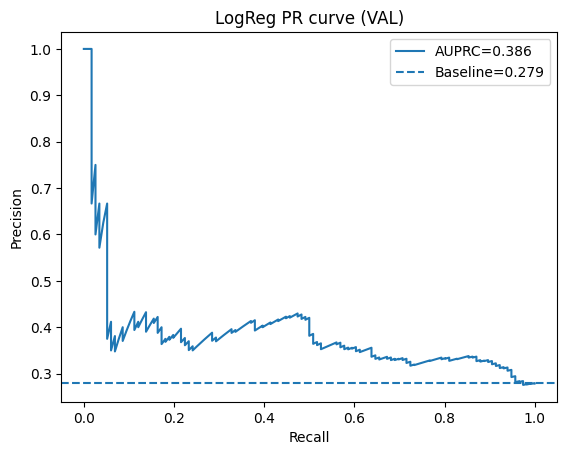

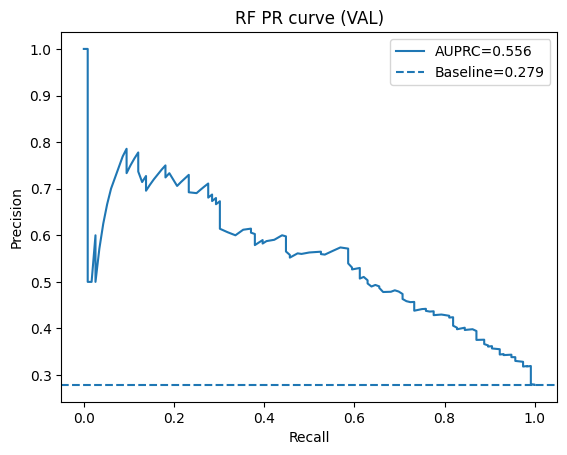

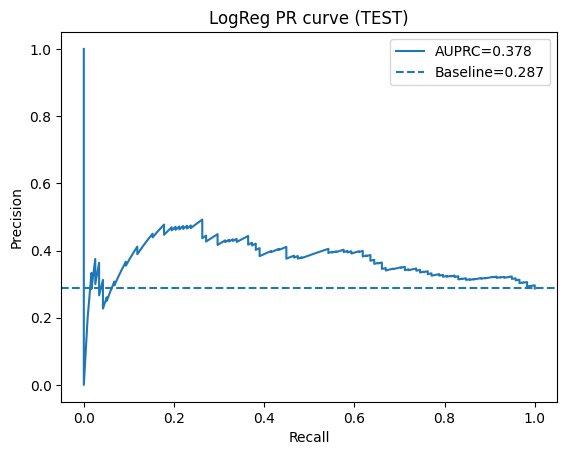

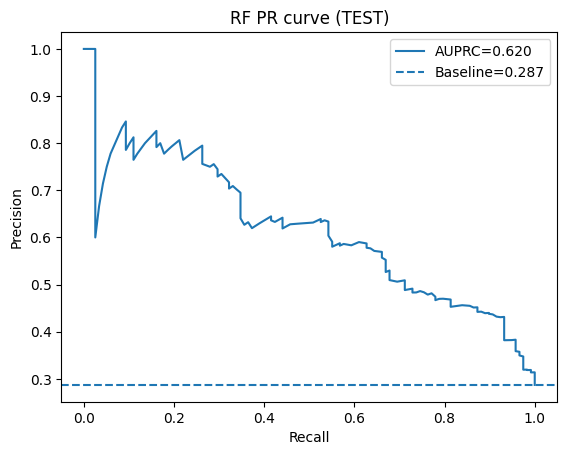

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

def plot_pr_curve(model, X, y, title="PR curve"):
    proba = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, proba)
    ap = average_precision_score(y, proba)
    baseline = np.mean(y)

    plt.figure()
    plt.plot(recall, precision, label=f"AUPRC={ap:.3f}")
    plt.axhline(baseline, linestyle="--", label=f"Baseline={baseline:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.show()

# PR curves on validation set
plot_pr_curve(logreg_model, X_val, y_val, title="LogReg PR curve (VAL)")
plot_pr_curve(rf_model, X_val, y_val, title="RF PR curve (VAL)")

# PR curves on test set (optional, can be shown once at the end)
plot_pr_curve(logreg_model, X_test, y_test, title="LogReg PR curve (TEST)")
plot_pr_curve(rf_model, X_test, y_test, title="RF PR curve (TEST)")


In [11]:
import pandas as pd
from pathlib import Path

# Put metrics into a simple table (manually from the variables you already computed)
results = [
    {
        "model": "LogReg",
        "val_AUROC": logreg_val["AUROC"],
        "val_AUPRC": logreg_val["AUPRC"],
        "val_F1": logreg_val["F1"],
        "val_BAcc": logreg_val["BalancedAcc"],
        "test_AUROC": logreg_test["AUROC"],
        "test_AUPRC": logreg_test["AUPRC"],
        "test_F1": logreg_test["F1"],
        "test_BAcc": logreg_test["BalancedAcc"],
    },
    {
        "model": "RandomForest",
        "val_AUROC": rf_val["AUROC"],
        "val_AUPRC": rf_val["AUPRC"],
        "val_F1": rf_val["F1"],
        "val_BAcc": rf_val["BalancedAcc"],
        "test_AUROC": rf_test["AUROC"],
        "test_AUPRC": rf_test["AUPRC"],
        "test_F1": rf_test["F1"],
        "test_BAcc": rf_test["BalancedAcc"],
    }
]

results_df = pd.DataFrame(results).sort_values(by="val_AUPRC", ascending=False)
display(results_df)

# Save in outputs (not processed_data)
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

out_path = OUT_DIR / "case1_model_results.csv"
results_df.to_csv(out_path, index=False)
print("Saved:", out_path)

# Pick best model based on validation AUPRC
best_model_name = results_df.iloc[0]["model"]
print("\nBest model based on val_AUPRC:", best_model_name)


,model,val_AUROC,val_AUPRC,val_F1,val_BAcc,test_AUROC,test_AUPRC,test_F1,test_BAcc
1,RandomForest,0.767716,0.555566,0.430939,0.62477,0.802872,0.619534,0.457143,0.640481
0,LogReg,0.627845,0.386361,0.444444,0.57454,0.631081,0.377731,0.467606,0.588896


Saved: outputs\case1_model_results.csv

Best model based on val_AUPRC: RandomForest


## 11. Feature importance and interpretation (Case 1 best model)
Using permutation_importance on validation set


In [12]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from pathlib import Path

# Use the best model: Random Forest
best_model = rf_model

# Compute permutation importance on the validation set
perm = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring="average_precision"  # AUPRC
)

feat_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

print("Top 15 most important features:")
display(feat_importance.head(15).to_frame("importance"))

# Group by signal name (II, V, PLETH)
signal_groups = {"II": [], "V": [], "PLETH": []}
for col in feature_cols:
    if col.startswith("II_"):
        signal_groups["II"].append(col)
    elif col.startswith("V_"):
        signal_groups["V"].append(col)
    elif col.startswith("PLETH_"):
        signal_groups["PLETH"].append(col)

signal_importance = {}
for sig, cols in signal_groups.items():
    signal_importance[sig] = float(feat_importance[cols].sum())

signal_importance = pd.Series(signal_importance).sort_values(ascending=False)

print("\nWaveform importance (sum of feature importances):")
display(signal_importance.to_frame("importance_sum"))

# Save results
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

feat_path = OUT_DIR / "case1_feature_importance.csv"
sig_path  = OUT_DIR / "case1_waveform_importance.csv"

feat_importance.to_csv(feat_path)
signal_importance.to_csv(sig_path)

print("Saved:", feat_path)
print("Saved:", sig_path)


Top 15 most important features:


,importance
II_linelen,0.054756
V_linelen,0.031099
PLETH_min,0.029258
II_ptp,0.027199
PLETH_max,0.020512
V_ptp,0.015741
II_max,0.009960
V_min,0.009564
PLETH_ptp,0.009475
V_max,0.007619



Waveform importance (sum of feature importances):


,importance_sum
II,0.110770
V,0.072561
PLETH,0.037419


Saved: outputs\case1_feature_importance.csv
Saved: outputs\case1_waveform_importance.csv


Test different combination av features and test it on RF

In [13]:
from sklearn.metrics import average_precision_score

def train_eval_rf(cols, name):
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample"
    )
    rf.fit(X_train[cols], y_train)
    proba = rf.predict_proba(X_val[cols])[:, 1]
    auprc = average_precision_score(y_val, proba)
    return {"setup": name, "n_features": len(cols), "val_AUPRC": auprc}

cols_II = [c for c in feature_cols if c.startswith("II_")]
cols_V = [c for c in feature_cols if c.startswith("V_")]
cols_P = [c for c in feature_cols if c.startswith("PLETH_")]

ablation_results = []
ablation_results.append(train_eval_rf(cols_II, "II only"))
ablation_results.append(train_eval_rf(cols_V, "V only"))
ablation_results.append(train_eval_rf(cols_P, "PLETH only"))
ablation_results.append(train_eval_rf(cols_II + cols_V, "II + V"))
ablation_results.append(train_eval_rf(cols_II + cols_P, "II + PLETH"))
ablation_results.append(train_eval_rf(cols_V + cols_P, "V + PLETH"))
ablation_results.append(train_eval_rf(cols_II + cols_V + cols_P, "II + V + PLETH (all)"))

ablation_df = pd.DataFrame(ablation_results).sort_values("val_AUPRC", ascending=False)
display(ablation_df)

ablation_df.to_csv(OUT_DIR / "case1_ablation_waveforms.csv", index=False)


,setup,n_features,val_AUPRC
4,II + PLETH,14,0.571088
6,II + V + PLETH (all),21,0.555566
3,II + V,14,0.533677
0,II only,7,0.515196
5,V + PLETH,14,0.503390
2,PLETH only,7,0.476719
1,V only,7,0.452292


In [14]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score
import pandas as pd

def rf_val_auprc(cols):
    rf = RandomForestClassifier(
        n_estimators=200,  # lite mindre för speed
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample"
    )
    rf.fit(X_train[cols], y_train)
    proba = rf.predict_proba(X_val[cols])[:, 1]
    return rf, average_precision_score(y_val, proba)

# Start with all features
current_cols = feature_cols.copy()
history = []

while len(current_cols) >= 5:
    rf, auprc = rf_val_auprc(current_cols)

    # permutation importance (keep repeats low for speed)
    perm = permutation_importance(
        rf, X_val[current_cols], y_val,
        n_repeats=5,
        random_state=RANDOM_SEED,
        scoring="average_precision"
    )
    imp = pd.Series(perm.importances_mean, index=current_cols).sort_values(ascending=True)

    history.append({"n_features": len(current_cols), "val_AUPRC": auprc})

    # Drop the 2 least important features each round (adjust if you want slower/finer)
    drop = imp.index[:2].tolist()
    current_cols = [c for c in current_cols if c not in drop]

rec_df = pd.DataFrame(history).sort_values("val_AUPRC", ascending=False)
display(rec_df)

best_n = int(rec_df.iloc[0]["n_features"])
print("Best number of features:", best_n)


,n_features,val_AUPRC
2,17,0.579818
3,15,0.574432
4,13,0.566386
1,19,0.564144
8,5,0.560664
7,7,0.554822
0,21,0.554213
5,11,0.552231
6,9,0.548353


Best number of features: 17


## 12. Recursive feature selection 

We iteratively remove the least important features (based on permutation importance)
and track validation AUPRC. This is a simple recursive feature elimination procedure.


In [15]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score
import pandas as pd

def rf_val_auprc(cols):
    rf = RandomForestClassifier(
        n_estimators=200,  # lite mindre för speed
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample"
    )
    rf.fit(X_train[cols], y_train)
    proba = rf.predict_proba(X_val[cols])[:, 1]
    return rf, average_precision_score(y_val, proba)

# Start with all features
current_cols = feature_cols.copy()
history = []

while len(current_cols) >= 5:
    rf, auprc = rf_val_auprc(current_cols)

    # permutation importance (keep repeats low for speed)
    perm = permutation_importance(
        rf, X_val[current_cols], y_val,
        n_repeats=5,
        random_state=RANDOM_SEED,
        scoring="average_precision"
    )
    imp = pd.Series(perm.importances_mean, index=current_cols).sort_values(ascending=True)

    history.append({"n_features": len(current_cols), "val_AUPRC": auprc})

    # Drop the 2 least important features each round (adjust if you want slower/finer)
    drop = imp.index[:2].tolist()
    current_cols = [c for c in current_cols if c not in drop]

rec_df = pd.DataFrame(history).sort_values("val_AUPRC", ascending=False)
display(rec_df)

best_n = int(rec_df.iloc[0]["n_features"])
print("Best number of features:", best_n)


,n_features,val_AUPRC
2,17,0.579818
3,15,0.574432
4,13,0.566386
1,19,0.564144
8,5,0.560664
7,7,0.554822
0,21,0.554213
5,11,0.552231
6,9,0.548353


Best number of features: 17


## 13. Case 2 (extended): define datasets (core vs all-5 drop)


In [16]:

# Case 2 signals
CASE2_CORE = ["II", "V", "PLETH"]                 # required in Case2_core
CASE2_ALL  = ["II", "V", "PLETH", "AVR", "ABP"]   # required in Case2_drop_all5

# Ensure sig_set exists
if "sig_set" not in df.columns:
    df["sig_set"] = df["sig_names"].apply(lambda lst: {str(s).strip().upper() for s in lst})

# Flags
df["case2_core_present"] = df["sig_set"].apply(lambda s: all(sig in s for sig in CASE2_CORE))
df["case2_all5_present"] = df["sig_set"].apply(lambda s: all(sig in s for sig in CASE2_ALL))

# Create datasets
df_case2_core = df[df["case2_core_present"] == True].copy()       # for imputation experiment
df_case2_drop = df[df["case2_all5_present"] == True].copy()       # drop strategy (no missing channels)

print("Total events:", len(df))
print("Case2_core (II+V+PLETH):", len(df_case2_core), f"({100*len(df_case2_core)/len(df):.2f}%)")
print("Case2_drop_all5 (II+V+PLETH+AVR+ABP):", len(df_case2_drop), f"({100*len(df_case2_drop)/len(df):.2f}%)")

# True/False per split for Case2_core
df_case2_core["decision_clean"] = df_case2_core["decision"].astype(str).str.strip().str.upper()
core_counts = pd.crosstab(df_case2_core["split"], df_case2_core["decision_clean"])
core_counts["TOTAL"] = core_counts.sum(axis=1)
core_pct = core_counts.div(core_counts["TOTAL"], axis=0) * 100

print("\nCase2_core: TRUE/FALSE per split (counts)")
display(core_counts)
print("\nCase2_core: TRUE/FALSE per split (percent)")
display(core_pct.round(2))

# Save small event lists 
case2_core_path = PROCESSED_DIR / "events_case2_core.csv"
case2_drop_path = PROCESSED_DIR / "events_case2_drop_all5.csv"
df_case2_core[["record","event","split","decision","y"]].to_csv(case2_core_path, index=False)
df_case2_drop[["record","event","split","decision","y"]].to_csv(case2_drop_path, index=False)
print("\nSaved:", case2_core_path)
print("Saved:", case2_drop_path)


Total events: 5030
Case2_core (II+V+PLETH): 4394 (87.36%)
Case2_drop_all5 (II+V+PLETH+AVR+ABP): 958 (19.05%)

Case2_core: TRUE/FALSE per split (counts)


decision_clean,FALSE,TRUE,TOTAL
split,,,
test,303,118,421
train,2558,990,3548
val,309,116,425



Case2_core: TRUE/FALSE per split (percent)


decision_clean,FALSE,TRUE,TOTAL
split,,,
test,71.97,28.03,100.0
train,72.10,27.90,100.0
val,72.71,27.29,100.0



Saved: processed_data\events_case2_core.csv
Saved: processed_data\events_case2_drop_all5.csv


## 14. Case 2: Extract features (II, V, PLETH, AVR, ABP)


In [17]:
import importlib
import utility_functions as uf
importlib.reload(uf)

PRE_SEC = 10
POST_SEC = 5
ONSET_SEC = 300
FS_EXPECTED = 250

CASE_2_SIGNALS = ["II","V","PLETH","AVR","ABP"]

feature_rows = []
fail_rows = []

for r, e in zip(df_case2_core["record"], df_case2_core["event"]):
    try:
        row = uf.extract_features_for_event_allow_missing(
            record_id=r,
            event_id=e,
            waveforms_dir=WAVEFORMS_DIR,
            signals=CASE_2_SIGNALS,
            pre_sec=PRE_SEC,
            post_sec=POST_SEC,
            onset_sec=ONSET_SEC,
            fs_expected=FS_EXPECTED
        )
        feature_rows.append(row)
    except Exception as ex:
        fail_rows.append({"record": r, "event": e, "error": str(ex)})

features_case2 = pd.DataFrame(feature_rows)

print("Extracted rows:", len(feature_rows))
print("Failed rows   :", len(fail_rows))

if len(feature_rows) == 0:
    print("\nAll extractions failed. First 5 errors:")
    print(pd.DataFrame(fail_rows).head())
else:
    tmp = pd.DataFrame(feature_rows)
    print("\nColumns in extracted features:")
    print(tmp.columns.tolist()[:30])
    display(tmp.head())


print("Case2_core events:", len(df_case2_core))
print("Feature rows extracted:", len(features_case2))
print("Failed extractions:", len(fail_rows))

# merge labels/split
features_case2 = features_case2.merge(
    df_case2_core[["record","event","split","decision","y"]],
    on=["record","event"],
    how="left"
)

# Missingness per feature
case2_feature_cols = [c for c in features_case2.columns
                      if any(c.startswith(s + "_") for s in CASE_2_SIGNALS)]

missing_pct = (features_case2[case2_feature_cols].isna().mean() * 100).sort_values(ascending=False)
print("\nMissing % per feature (top 10):")
display(missing_pct.head(10).to_frame("missing_pct"))

# Save features
features2_path = PROCESSED_DIR / "features_case2.csv"
features_case2.to_csv(features2_path, index=False)
print("\nSaved:", features2_path)


Extracted rows: 4391
Failed rows   : 3

Columns in extracted features:
['record', 'event', 'fs', 'II_mean', 'II_std', 'II_min', 'II_max', 'II_ptp', 'II_rms', 'II_linelen', 'V_mean', 'V_std', 'V_min', 'V_max', 'V_ptp', 'V_rms', 'V_linelen', 'PLETH_mean', 'PLETH_std', 'PLETH_min', 'PLETH_max', 'PLETH_ptp', 'PLETH_rms', 'PLETH_linelen', 'AVR_mean', 'AVR_std', 'AVR_min', 'AVR_max', 'AVR_ptp', 'AVR_rms']


,record,event,fs,II_mean,II_std,II_min,II_max,II_ptp,II_rms,II_linelen,...,AVR_ptp,AVR_rms,AVR_linelen,ABP_mean,ABP_std,ABP_min,ABP_max,ABP_ptp,ABP_rms,ABP_linelen
0,003c13,003c13_0115,250,-0.008637,0.177324,-0.440003,0.935029,1.375032,0.177535,127.684922,...,0.849971,0.106645,84.653731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,003c13,003c13_0126,250,-0.001039,0.177053,-0.360011,0.924996,1.285008,0.177056,125.694006,...,0.915000,0.106164,90.389860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,004bad,004bad_0015,250,0.117391,0.960125,-10.180360,1.889461,12.069820,0.967275,154.681022,...,13.274899,1.134001,148.361844,85.446871,22.554443,-27.002904,186.185724,213.188628,88.373472,7635.074949
3,004bad,004bad_1115,250,0.069043,0.659609,-3.255062,7.150031,10.405093,0.663213,100.608654,...,5.160024,0.380174,78.127448,72.744940,25.136724,47.250765,129.686707,82.435942,76.965455,3480.761214
4,004bad,004bad_1426,250,0.108270,0.197246,-0.265001,1.074992,1.339993,0.225007,89.601199,...,NaN,NaN,NaN,79.657027,19.977191,48.312753,145.563301,97.250549,82.123870,2979.197001


Case2_core events: 4394
Feature rows extracted: 4391
Failed extractions: 3

Missing % per feature (top 10):


,missing_pct
ABP_min,64.518333
ABP_mean,64.518333
ABP_rms,64.518333
ABP_linelen,64.518333
ABP_ptp,64.518333
ABP_max,64.518333
ABP_std,64.518333
AVR_ptp,34.866773
AVR_rms,34.866773
AVR_linelen,34.866773



Saved: processed_data\features_case2.csv


## 15. Case 2: Compare drop vs impute (LogReg vs RF)


In [18]:
features_case2 = pd.read_csv(PROCESSED_DIR / "features_case2.csv")
print("Loaded features_case2:", features_case2.shape)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, balanced_accuracy_score
from pathlib import Path
import pandas as pd
import numpy as np

def evaluate(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "AUROC": roc_auc_score(y, proba) if len(np.unique(y)) > 1 else np.nan,
        "AUPRC": average_precision_score(y, proba),
        "F1": f1_score(y, pred),
        "BAcc": balanced_accuracy_score(y, pred),
    }

def run_one_setting(df_feat, setting_name, use_impute):
    # Split
    tr = df_feat[df_feat["split"]=="train"].copy()
    va = df_feat[df_feat["split"]=="val"].copy()
    te = df_feat[df_feat["split"]=="test"].copy()

    X_train, y_train = tr[case2_feature_cols], tr["y"].astype(int)
    X_val, y_val     = va[case2_feature_cols], va["y"].astype(int)
    X_test, y_test   = te[case2_feature_cols], te["y"].astype(int)

    # Models
    if use_impute:
        logreg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
        ])
        rf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED,
                                          class_weight="balanced_subsample"))
        ])
    else:
        # no imputer (we assume df_feat already had NaNs dropped)
        logreg = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
        ])
        rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED,
                                    class_weight="balanced_subsample")

    # Fit + eval
    logreg.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    out = []
    for model_name, model in [("logreg", logreg), ("rf", rf)]:
        val_m = evaluate(model, X_val, y_val)
        test_m = evaluate(model, X_test, y_test)
        out.append({
            "setting": setting_name,
            "model": model_name,
            "n_train": len(X_train),
            "n_val": len(X_val),
            "n_test": len(X_test),
            "val_AUROC": val_m["AUROC"],
            "val_AUPRC": val_m["AUPRC"],
            "val_F1": val_m["F1"],
            "val_BAcc": val_m["BAcc"],
            "test_AUROC": test_m["AUROC"],
            "test_AUPRC": test_m["AUPRC"],
            "test_F1": test_m["F1"],
            "test_BAcc": test_m["BAcc"],
        })
    return out, logreg, rf


# Strategy 1: DROP
features_case2_drop = features_case2.dropna(subset=case2_feature_cols).copy()
print("Case2 DROP rows:", len(features_case2_drop), "out of", len(features_case2))

drop_rows, drop_logreg, drop_rf = run_one_setting(features_case2_drop, "case2_drop", use_impute=False)

# Strategy 2: IMPUTE
impute_rows, impute_logreg, impute_rf = run_one_setting(features_case2, "case2_impute", use_impute=True)

# Collect results
results_case2 = pd.DataFrame(drop_rows + impute_rows).sort_values(["setting","model"])
display(results_case2)

# Set path
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# Timestamp (include time to avoid overwriting)
timestamp = datetime.now().strftime("%y%m%d%H%M")

# Helper: get val_BAcc for a specific (setting, model)
def get_val_bacc(results_df, setting, model_name):
    row = results_df[(results_df["setting"] == setting) & (results_df["model"] == model_name)].iloc[0]
    return float(row["val_BAcc"])

# Save a model in a folder: type_accuracy_timestamp
def save_model(model_obj, model_tag, val_bacc):
    score = int(round(val_bacc * 100))
    folder = MODELS_DIR / f"{model_tag}_{score}_{timestamp}"
    folder.mkdir(parents=True, exist_ok=True)

    path = folder / "model.joblib"
    joblib.dump(model_obj, path)
    return path

# ---- Save all 4 models ----
paths = []

# DROP models
paths.append(save_model(drop_logreg, "case2drop_logreg", get_val_bacc(results_case2, "case2_drop", "logreg")))
paths.append(save_model(drop_rf,     "case2drop_rf",     get_val_bacc(results_case2, "case2_drop", "rf")))

# IMPUTE models
paths.append(save_model(impute_logreg, "case2impute_logreg", get_val_bacc(results_case2, "case2_impute", "logreg")))
paths.append(save_model(impute_rf,     "case2impute_rf",     get_val_bacc(results_case2, "case2_impute", "rf")))

print("\nSaved Case 2 models:")
for p in paths:
    print("-", p)


# Save results
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
results_case2.to_csv(OUT_DIR / "case2_results_drop_vs_impute.csv", index=False)
print("Saved:", OUT_DIR / "case2_results_drop_vs_impute.csv")


Loaded features_case2: (4391, 41)
Case2 DROP rows: 926 out of 4391


,setting,model,n_train,n_val,n_test,val_AUROC,val_AUPRC,val_F1,val_BAcc,test_AUROC,test_AUPRC,test_F1,test_BAcc
0,case2_drop,logreg,715,95,116,0.733020,0.483342,0.531250,0.656740,0.724717,0.508864,0.609756,0.734210
1,case2_drop,rf,715,95,116,0.812435,0.683881,0.631579,0.734587,0.739138,0.542666,0.526316,0.673056
2,case2_impute,logreg,3545,425,421,0.662928,0.466757,0.457143,0.595637,0.703446,0.456371,0.514793,0.649172
3,case2_impute,rf,3545,425,421,0.796117,0.563197,0.459016,0.640581,0.828593,0.653672,0.513966,0.670163



Saved Case 2 models:
- models\case2drop_logreg_66_2602071754\model.joblib
- models\case2drop_rf_73_2602071754\model.joblib
- models\case2impute_logreg_60_2602071754\model.joblib
- models\case2impute_rf_64_2602071754\model.joblib
Saved: outputs\case2_results_drop_vs_impute.csv


## 16. Discussion + limitations

- Missingness is **not random** (some sensors are not connected) → dropping rows can change the dataset distribution.
- We used AUPRC because the dataset is imbalanced.
- Feature importance/ablation helps interpret which waveforms drive predictions.

**see Report for more information**